# Figure generation for Samson

In [ ]:
folder = './figures/'
savefig:bool = False

n_original =  5 # before dimensionality reduction
s_original =  3 # space between consecutive gray bands (before reduction)

n_pca =  2 # after dimensionality reduction
s_pca =  9 # space between consecutive gray bands (after reduction)

res = 1 # image downsampling resolution (useful for large images)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional, Literal

from unmixing import normed, normalized, preprocess_image
from unmixing import extract_random_sample, data_in_polyhedron
from unmixing import get_extrema_val, uniformize_data

#### **Import dataset**

In [ ]:
# Import Samson dataset

image_path = "./datasets/samson/samson.mat"
label_path = "./datasets/samson/ground_truth.mat"

from unmixing import import_mlab_image

image = import_mlab_image(image_path, image_key='V')
image = image.T.reshape(int(np.round(np.sqrt(image.shape[-1]))), int(np.round(np.sqrt(image.shape[-1]))), image.shape[0]).swapaxes(0,1)

label = import_mlab_image(label_path, image_key='A')
label = label.T.reshape(int(np.round(np.sqrt(label.shape[-1]))), int(np.round(np.sqrt(label.shape[-1]))), label.shape[0]).swapaxes(0,1)

label_spectra = import_mlab_image(label_path, image_key='M')
label_spectra = label_spectra.T

In [4]:
print("Image size:",image.shape[:-1],"\nBands:",image.shape[-1])

Image size: (95, 95) 
Bands: 156


#### **Show dataset**

In [5]:
# Define display functions

def get_original_img(img:np.ndarray) -> np.ndarray:
    return normalized(np.transpose((
        normalized(  0.6 * normalized(img[:,:,98]) + 0.2 * normalized(img[:,:,90]) + 0.7 * normalized(img[:,:,50])), 
        normalized(  0.1 * normalized(img[:,:,98]) - 0.3 * normalized(img[:,:,90]) + 0.8 * normalized(img[:,:,50])), 
        normalized(- 0.5 * normalized(img[:,:,98]) + 0.4 * normalized(img[:,:,90]) + 0.9 * normalized(img[:,:,50])), 
        np.ones(shape=img.shape[:-1], dtype=img.dtype)
    ), axes=(1,2,0)))

def get_reduced_img(img:np.ndarray) -> np.ndarray:
    return normalized(np.transpose((
        normalized(  0.6 * normalized(img[:,:,0]) + 0.2 * normalized(img[:,:,1]) + 0.0 * normalized(img[:,:,2])), 
        normalized(  0.4 * normalized(img[:,:,0]) - 0.7 * normalized(img[:,:,1]) + 0.8 * normalized(img[:,:,2])), 
        normalized(- 0.5 * normalized(img[:,:,0]) + 0.4 * normalized(img[:,:,1]) + 0.9 * normalized(img[:,:,2])), 
        np.ones(shape=img.shape[:-1], dtype=img.dtype)
    ), axes=(1,2,0)))

def spectral_image_show(
        img:np.ndarray, 
        nbands:Optional[int]=None, 
        nwhite:Optional[int]=None, 
        band_sort_type:Literal['uniform','firsts']='uniform',
        front:Optional[np.ndarray|Literal['original','reduced']]=None
) -> np.ndarray:
    if type(front) is str:
        if front.lower() == 'original':
            front = get_original_img(img)
        elif front.lower() == 'reduced':
            front = get_reduced_img(img)
        else:
            front = None
    d = img.shape[-1] if nbands is None else nbands
    w = 0 if nwhite is None else nwhite
    if band_sort_type.lower() == 'uniform':
        l = np.floor(np.linspace(0, img.shape[-1]-1, num=d)).astype(int)
    elif band_sort_type.lower() == 'firsts':
        l = np.arange(d).astype(int)
    else:
        raise ValueError("Argument band_sort_type must be either 'uniform' or 'firsts'")
    sim = np.ones(shape=(img.shape[0]+d+d*w, img.shape[1]+d+d*w, 4), dtype=np.float32)
    sim[:,:,-1] = 0
    if front is not None:
        if front.ndim == 2:
            front = front[...,None]
        elif front.ndim == 3 and front.shape[-1] == 3:
            front = np.concatenate([front, np.ones(front.shape[:-1]+(1,), dtype=front.dtype)], axis=-1)
        sim[d*(w+1):d*(w+1)+img.shape[0], 0:img.shape[1]] = front.astype(np.float32)
    for i in range(d):
        num = l[i]
        iim = np.asarray(list(normalized((img)[:,:,num,None]).T)*3).T
        sim[(d-i)*(w+1)-w-1:(d-i)*(w+1), w+1+i*(w+1):img.shape[1]+i*(w+1)] = np.append(iim[:1+w, :-1-w], np.ones(shape=(1+w,iim.shape[1]-1-w,1), dtype=np.float32), axis=-1)
        sim[(d-i)*(w+1)-w-1:(d-i)*(w+1)-w-1+img.shape[0], img.shape[1]+i*(w+1):img.shape[1]+i*(w+1)+w+1] = np.append(iim[:, -1-w:], np.ones(shape=(iim.shape[0],1+w,1), dtype=np.float32), axis=-1)
    return sim

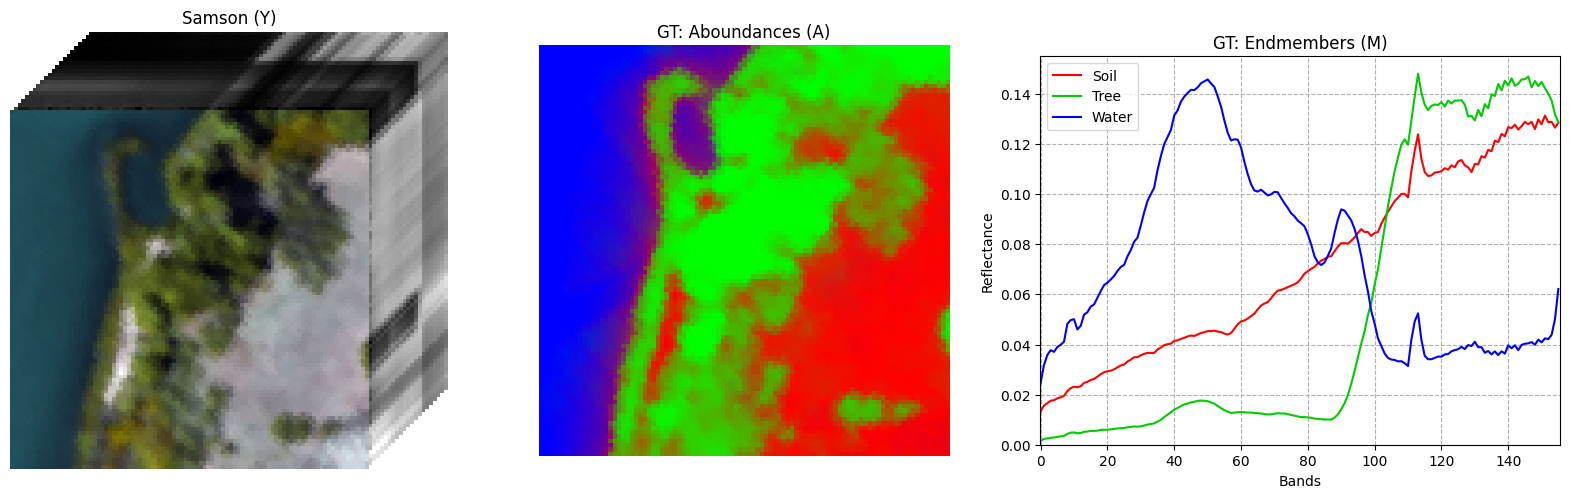

In [ ]:
fig, ax = plt.subplots(1, 3, gridspec_kw={'width_ratios': [80, 75, 95]}, figsize=(20,6))

ax[0].imshow(spectral_image_show(image[::res,::res], 21, None, 'uniform', 'original'))
ax[0].set_axis_off()
ax[0].set_title("Samson (Y)")

ax[1].imshow(normalized(label)[::res,::res])
ax[1].set_axis_off()
ax[1].set_title("GT: Aboundances (A)")

X = np.arange(label_spectra.shape[1])
for i in range(label_spectra.shape[0]):
    ax[2].plot(X, normed(label_spectra[i]), c=(int(i==0), 0.8*int(i==1), int(i==2)), label = "Soil" * int(i==0) + "Tree" * int(i==1) + "Water" * int(i==2))
ax[2].legend()
ax[2].set_xlim(-0.1,155.5)
ax[2].set_ylim(0,0.155)
ax[2].set_ylabel("Reflectance")
ax[2].set_xlabel("Bands")
ax[2].grid(linestyle="--")
ax[2].set_aspect(750)
ax[2].set_title("GT: Endmembers (M)")

plt.show()

#### **Set matplotlib font**

In [9]:
plt.rcParams.update({
    "text.usetex": True,                     # Utilise LaTeX pour le texte
    "font.family": "serif",                  # Famille de base
    "font.serif": ["Computer Modern Roman"], 
    "axes.labelsize": 12,                    # Taille des labels axes
    "font.size": 12,                         # Taille police globale
    "legend.fontsize": 10, 
    "xtick.labelsize": 10, 
    "ytick.labelsize": 10, 
    "figure.dpi": 150, 
    "savefig.dpi": 300, 
    "text.latex.preamble": r"\usepackage{amsmath}"  # pour équations si besoin
})

### **Polyhedral Unmixing Pipeline**
#### **A. Original dataset:** Samson
##### **1.** Dataset Y

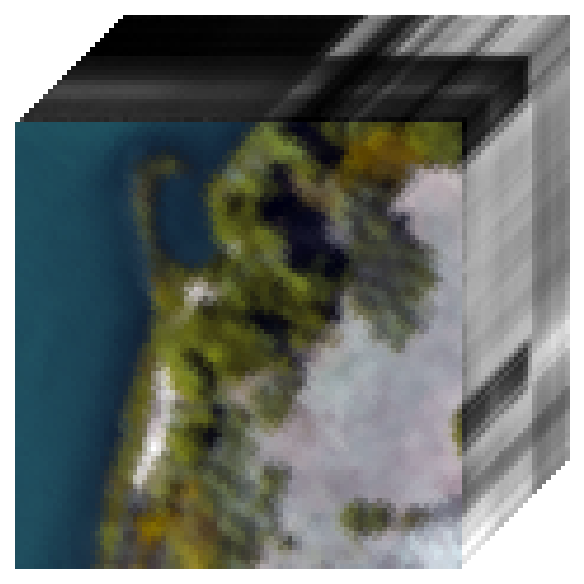

In [ ]:
name = 'samson_y'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(image[::res,::res,1:], int(image.shape[-1]*3/20), 0, 'uniform', 'original'))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

##### **2.** Ground-Truth Abundance Map A

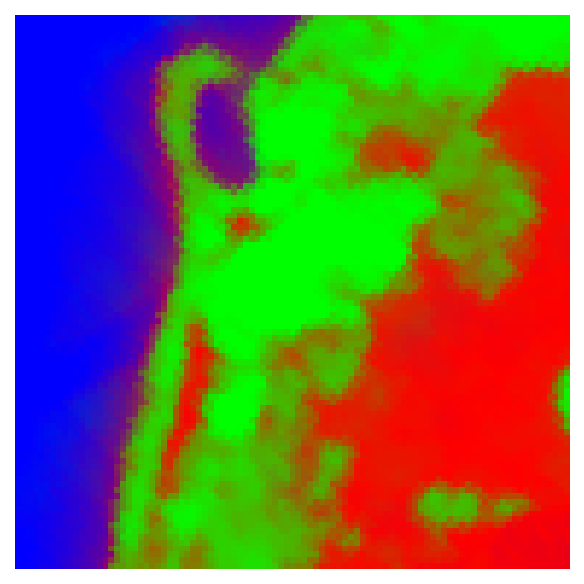

In [ ]:
name = 'samson_a'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(image[::res,::res], 0, 0, front=normalized(label)[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

##### **3.** Ground-Truth Classification Map C

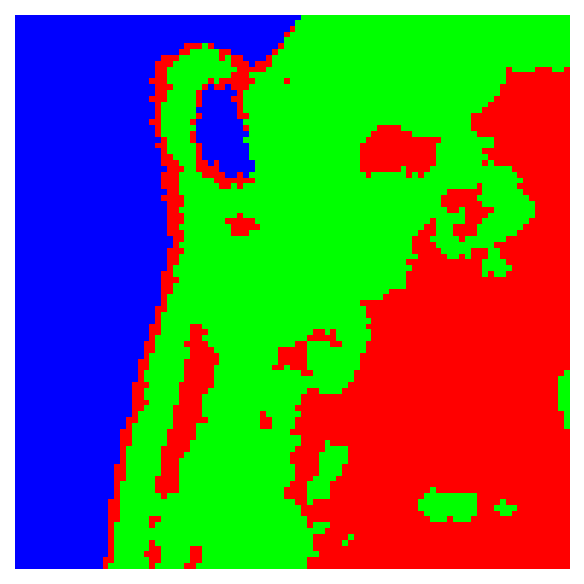

In [ ]:
name = 'samson_c'

class_img = np.zeros(shape=image.shape[:-1]+(3,), dtype=np.uint8)
for i in range(3):
    image_class = np.argmax(label, axis=-1) == i
    class_img[image_class,i] = 255

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(class_img[::res,::res]) #ax.imshow(class_img.argmax(-1)[::res,::res])
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

##### **4.** Ground-Truth Endmembers M

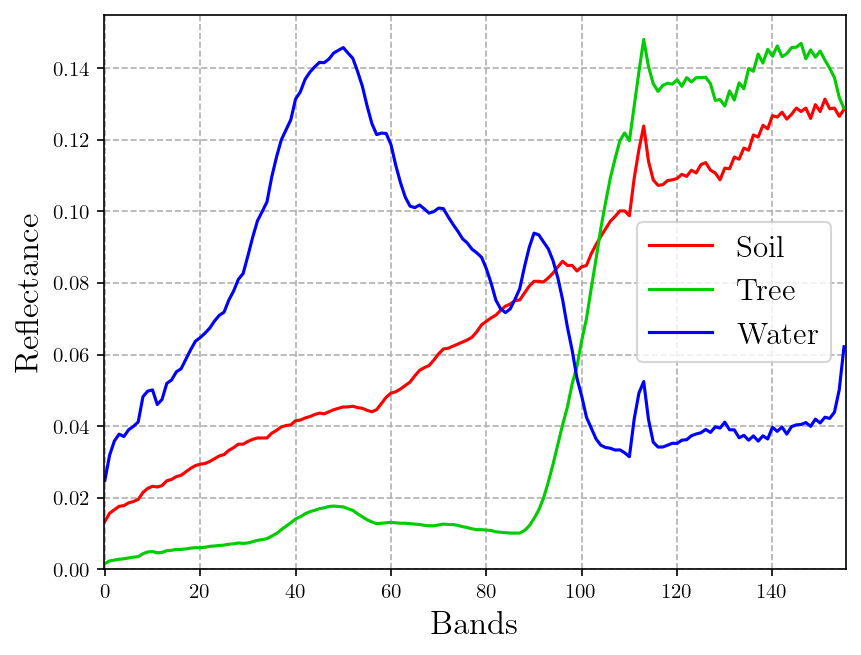

In [13]:
name = 'samson_m'

fig, ax = plt.subplots()

X = np.arange(label_spectra.shape[1])
for i in range(label_spectra.shape[0]):
    ax.plot(X, normed(label_spectra[i]), c=(int(i==0), 0.8*int(i==1), int(i==2)), label = "Soil" * int(i==0) + "Tree" * int(i==1) + "Water" * int(i==2))
ax.legend(fontsize=int(15))
ax.set_xlim(-0.1,155.5)
ax.set_ylim(0,0.155)
ax.set_ylabel("Reflectance", fontsize=16)
ax.set_xlabel("Bands", fontsize=16)
ax.grid(linestyle="--")
ax.set_aspect(750)

if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **B. Preprocessing:** luminance normalization and dimensionality reduction

In [14]:
homoReduced_image = preprocess_image(
    image, 
    homogenize_luminance = True, 
    ndim_PCA_reduction = 12
)

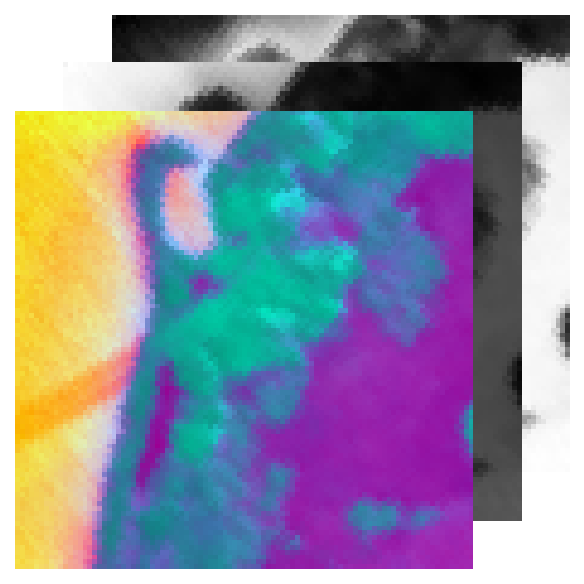

In [ ]:
name = 'samson_y_homoRedu'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', 'reduced'))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **C. Semantic Segmentation:** unsupervised pixel Classification / Clustering

In [ ]:
from sklearn.mixture import GaussianMixture
from unmixing import reorder_C

sample_prop = 0.2
init = label_spectra.shape[0]
n_init = 10

homoReduced_data = homoReduced_image.reshape(np.prod(homoReduced_image.shape[:-1]), homoReduced_image.shape[-1])
homoReduced_sample = extract_random_sample(homoReduced_data, prop=sample_prop)

if type(init) is np.ndarray:
    n = init.shape[0]
    init_means = init
else:
    n = int(np.round(init))
    init_means = None
gmm = GaussianMixture(n_components=n, covariance_type='full', init_params='kmeans', n_init=n_init, means_init=init_means).fit(X=homoReduced_sample)
GMM_labels = gmm.predict(X=homoReduced_data)

GMM_labels = reorder_C(GMM_labels, np.argmax(label, axis=-1).flatten())
GMM_image = GMM_labels.reshape(*image.shape[:-1])

image_labels = np.ones(image.shape[:-1]+(4,), dtype=np.bool_)
for i in range(3):
    image_labels[..., i] = GMM_image == i

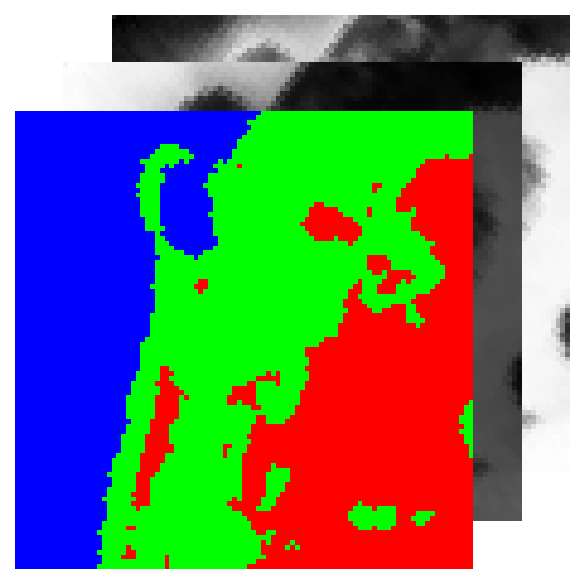

In [ ]:
name = 'samson_y_GMMclass'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', image_labels[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **D. Polyhedral Partitioning:** via (un)biased SVM

In [22]:
from unmixing import ovo_unbiased_linear_svm, to_half_space_couples
from unmixing import distribute_half_spaces, keep_only_necessary_couples

sample_prop = 0.2

gmm_means = np.array([np.mean(homoReduced_data[GMM_labels==i], axis=0) for i in range(label.shape[-1])])

homoReduced_sample_SVM, sample_idx = extract_random_sample(homoReduced_data, prop=sample_prop, return_indices=True)
GMM_restr_labels = GMM_labels[sample_idx]

w = ovo_unbiased_linear_svm(X=homoReduced_sample_SVM, y=GMM_restr_labels)
h_hyperplanes = to_half_space_couples(w, np.zeros(shape=w.shape[:-1]))
h_half_spaces = list(distribute_half_spaces(h_hyperplanes, gmm_means))
for _ in range(len(h_half_spaces)):
    h0 = h_half_spaces.pop(0)
    hp = keep_only_necessary_couples(h0)
    h_half_spaces.append(hp)

image_newLabels = np.ones(image.shape[:-1]+(4,), dtype=np.bool_)
for i in range(len(h_half_spaces)):
    in_poly = data_in_polyhedron(data=homoReduced_data, polyhedron=h_half_spaces[i])
    image_newLabels[..., i] = in_poly.reshape(*image.shape[:-1])

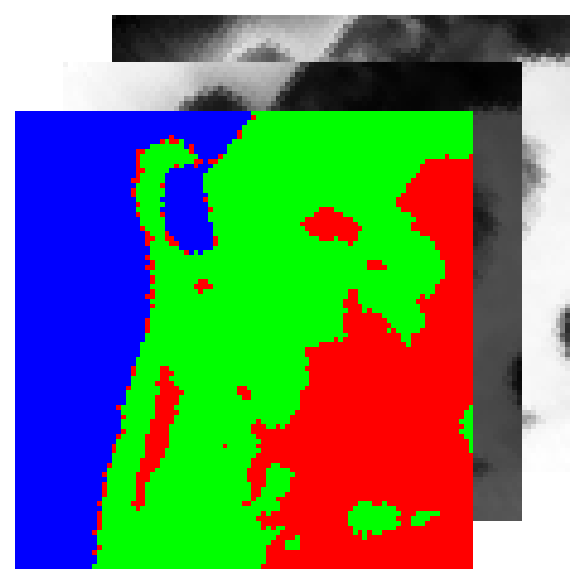

In [ ]:
name = 'samson_y_SVMclass'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', image_newLabels[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **E. Signed Distance Computation:** using a minimum-norm point solver in polyhedral sets

In [25]:
from figure_generation_func import quick_distances # ONLY for polyhedra made of 2 halfspaces!!!

dist_q = quick_distances(data=homoReduced_data, h=h_half_spaces)
dist_img = dist_q.reshape(*image.shape[:-1], len(h_half_spaces))
#dist_show = normalized( - dist_img )# * (dist_img < 0) )# , axis=(0,1)) ###
dist_show = np.tanh( dist_img / dist_img.min() * (dist_img < 0) * 1.5 ) ###
dist_show = dist_show / dist_show.max()

dist_show_fus = normalized(dist_show)

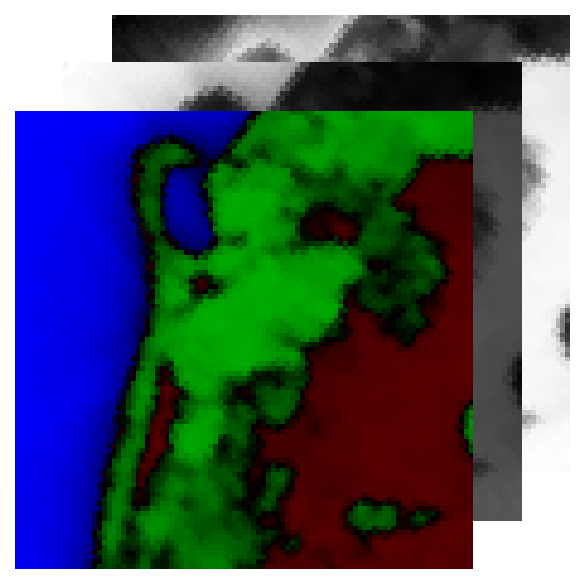

In [ ]:
name = 'samson_y_polyDist'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', dist_show_fus[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **F. Change of basis:** contributions of reference distance vectors

In [28]:
dis_extrema = get_extrema_val(dist_q, dist_q)
unidis_q = uniformize_data(data=dist_q, references=dis_extrema)
unidis_img = unidis_q.reshape(*image.shape[:-1], len(h_half_spaces))
unidis_img[unidis_img < 0] = 0; unidis_img[unidis_img > 1] = 1

unidis_img_fus = normalized(unidis_img)

Data projected in orthonormalized references' space
=> Linear transform


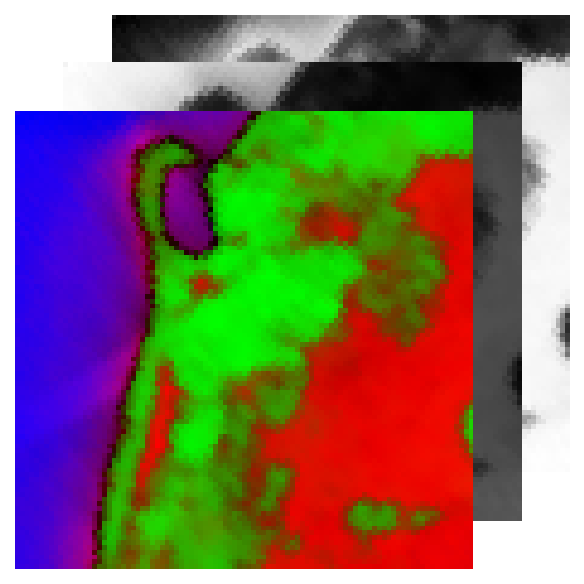

In [ ]:
name = 'samson_y_distContrib'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', unidis_img_fus[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()

#### **G. Transformation to abundances:** via projection onto the probability simplex

In [30]:
# May take about 2 minutes!
from unmixing import to_probability

# Define projection depth
simplex_depth = 2.5

# Project distance data - 3D
Yprob = to_probability(unidis_q / (simplex_depth * unidis_q.std()))
prob_img = Yprob.reshape(*image.shape[:-1], len(h_half_spaces))

prob_img_fus = normalized(prob_img)

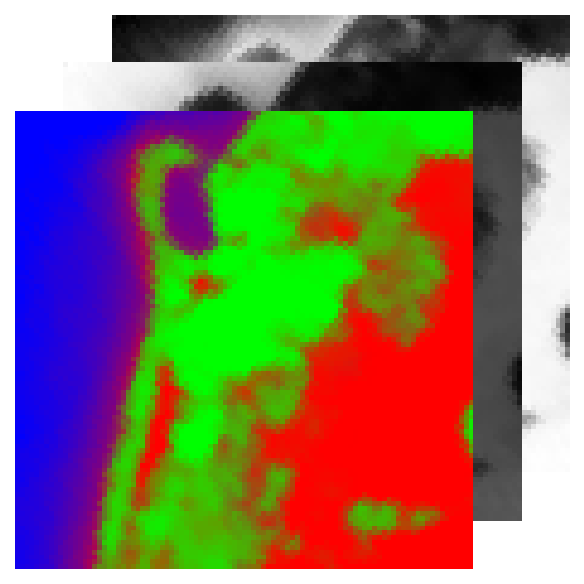

In [ ]:
name = 'samson_y_finalProba'

fig, ax = plt.subplots(); ax.set_axis_off()
ax.imshow(spectral_image_show(homoReduced_image[::res,::res], n_pca, s_pca, 'firsts', prob_img_fus[::res,::res]))
if savefig:
    fig.savefig(folder + name + '.pdf', bbox_inches='tight', pad_inches=0, transparent=True)
else:
    plt.show()